In [7]:
import numpy as np
import pandas as pd
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

import sys
import os

parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))

if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

from core_solver import factors_for_unit_conversion

plt.rcParams.update({
    "text.usetex": True,                
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "figure.dpi": 150,                   
    "grid.alpha": 0.4,                    
})

# Generate Quark Matter EoS


In [8]:
# ---------------------------------------------------------
# 1.1 Thermodynamic Functions
# ---------------------------------------------------------
def fermi_momentum(mu, m):
    """Input is chemical potential (mu) and mass (m) in units of MeV. Returns Fermi momentum kF."""
    return np.sqrt(np.maximum(mu**2 - m**2, 0.0))

def number_density(g, mu, m):
    """Computes number density n for degeneracy g in units of MeV^3."""
    if mu <= m:
        return 0.0
    kF = fermi_momentum(mu, m)
    return (g / (6 * np.pi**2)) * kF**3

def energy_density_f(g, mu, m):
    """Computes energy density contribution of a single fermion in units of MeV^4."""
    if mu <= m:
        return 0.0
    if m < 1e-10:
        return (g / (16 * np.pi**2)) * (2 * mu**4)  # Massless limit
    
    kF = fermi_momentum(mu, m)
    # Standard zero-temperature Fermi gas energy integral evaluation
    term1 = kF * mu * (2 * kF**2 + m**2)
    term2 = m**4 * np.log((kF + mu) / m)
    return (g / (16 * np.pi**2)) * (term1 - term2)

def pressure_f(g, mu, m):
    """Computes pressure contribution of a single fermion in units of MeV^4."""
    if mu <= m:
        return 0.0
    if m < 1e-10:
        return (g / (48 * np.pi**2)) * (2 * mu**4)  # Massless limit
    kF = fermi_momentum(mu, m)
    term1 = kF * mu * (2 * kF**2 - 3 * m**2)
    term2 = 3 * m**4 * np.log((kF + mu) / m)
    return (g / (48 * np.pi**2)) * (term1 + term2)

# ---------------------------------------------------------
# 1.2 The System of Equations for fsolve
# ---------------------------------------------------------

def beta_equilibrium_system(x, nB_target, masses):
    """
    x = [mu_u, mu_e]
    masses = (m_u, m_d, m_s, m_e)
    """
    mu_u, mu_e = x
    m_u, m_d, m_s, m_e = masses
    
    # Apply your analytical substitutions!
    mu_d = mu_u + mu_e
    mu_s = mu_d
    
    # Calculate number densities
    n_u = number_density(6, mu_u, m_u)
    n_d = number_density(6, mu_d, m_d)
    n_s = number_density(6, mu_s, m_s)
    n_e = number_density(2, mu_e, m_e)
    
    # Return exactly 2 equations to match the 2 variables
    eq_charge = (2/3)*n_u - (1/3)*n_d - (1/3)*n_s - n_e
    eq_baryon = (1/3)*(n_u + n_d + n_s) - nB_target
    
    return [eq_charge, eq_baryon]

In [9]:
# ---------------------------------------------------------
# 2. Find minimum value (Zero Pressure Condition)
# ---------------------------------------------------------

def find_nb_for_zero_pressure(masses, B_bag, nB_guess=[1e-2]):

    guess = [200, 0] # Your scaled units guess
    m_u, m_d, m_s, m_e = masses
    
    def objective(nB_val): 
        nb_scalar = nB_val[0] 
        
        # Find chemical potentials that satisfy beta equilibrium and charge neutrality for this nB
        sol = fsolve(beta_equilibrium_system, guess, args=(nb_scalar, masses))
        
        mu_u, mu_e = sol
        mu_d = mu_u + mu_e
        mu_s = mu_d 
        
        p_u = pressure_f(6, mu_u, m_u)
        p_d = pressure_f(6, mu_d, m_d)
        p_s = pressure_f(6, mu_s, m_s)
        p_e = pressure_f(2, mu_e, m_e)
        
        pressure_total = (p_u + p_d + p_s + p_e) - B_bag
        return pressure_total

    # Solve for nB where pressure is 0
    optimal_nB = fsolve(objective, nB_guess)
    return optimal_nB[0]



In [10]:

# ---------------------------------------------------------
# 3. Generate the EoS Table
# ---------------------------------------------------------
def generate_quark_eos(masses, B_bag, nB_grid):
    m_u, m_d, m_s, m_e = masses
    results = []
    
    current_guess = [200, 0] 
    
    for nB in nB_grid:
        sol = fsolve(beta_equilibrium_system, current_guess, args=(nB, masses))
        mu_u, mu_e = sol
        
        # Update guess for the next loop so it stays fast
        current_guess = sol 
        
        # Apply your substitutions
        mu_d = mu_u + mu_e
        mu_s = mu_d
        
        e_tot = (energy_density_f(6, mu_u, m_u) + energy_density_f(6, mu_d, m_d) + 
                 energy_density_f(6, mu_s, m_s) + energy_density_f(2, mu_e, m_e) + B_bag)
        
        p_tot = (pressure_f(6, mu_u, m_u) + pressure_f(6, mu_d, m_d) + 
                 pressure_f(6, mu_s, m_s) + pressure_f(2, mu_e, m_e) - B_bag)
        
        if p_tot >= 0:
            results.append({
                "Number Density": nB / (4*B_bag)**(3/4), "Energy Density": e_tot / (4*B_bag), "Pressure": p_tot / (4*B_bag),
                "mu_u": mu_u, "mu_d": mu_d, "mu_s": mu_s, "mu_e": mu_e
            })
            
    return pd.DataFrame(results)

EoS successfully generated and saved.


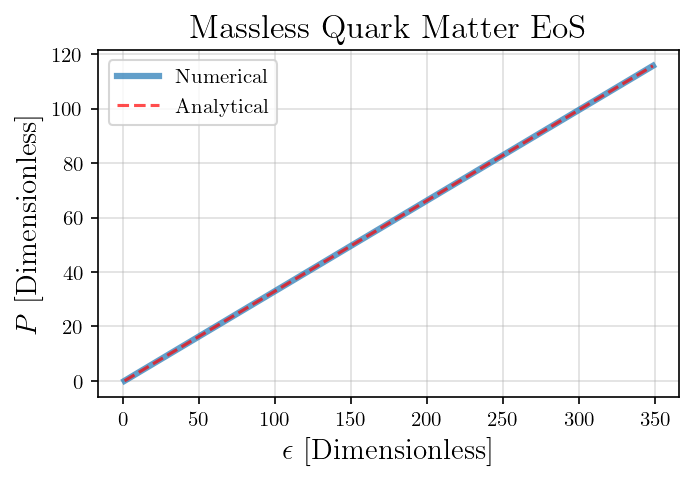

Minimum Pressure: 3.850e-01 MeV/fm^3 at Energy Density: 1.005e+00 MeV/fm^3


In [11]:
# ---------------------------------------------------------
# 4. Analytical Check for Massless Quarks
# ---------------------------------------------------------

# Define parameters for massless quark test
masses_massless = (0.0, 0.0, 0.0, 0.511)
B = 148
B_val = (B)**4

# 1. Find where to start
nB_minimum = find_nb_for_zero_pressure(masses_massless, B_val, nB_guess=[10e6])

# 2. Build grid from surface upwards
grid_massless = np.logspace(np.log10(nB_minimum), np.log10(nB_minimum*100), 1000)

# 3. Generate
df_massless = generate_quark_eos(masses_massless, B_val, grid_massless)

df_massless.to_csv("../data/eos_library/quark_matter_massless.csv", index=False)
print("EoS successfully generated and saved.")

# 4. Change to dimensionless units
units = factors_for_unit_conversion(B)
e_dimless = df_massless["Energy Density"]  
p_dimless = df_massless["Pressure"]  

# 5. Check analytical P = (e - 4B)/3
analytical_p = (e_dimless  -1  ) / 3




plt.figure(figsize=(5,3))
plt.plot(e_dimless, p_dimless, label="Numerical", lw=3, alpha=0.7)
plt.plot(e_dimless, analytical_p, '--', label="Analytical", color="red", alpha=0.7)
plt.xlabel(r"$\epsilon$ [Dimensionless] ", fontsize=14)
plt.ylabel(r"$P$ [Dimensionless]", fontsize=14)
plt.title("Massless Quark Matter EoS", fontsize=16)
plt.legend()
plt.grid()
plt.show()

min_pressure_index = df_massless["Pressure"].idxmin()
min_pressure_value = df_massless["Pressure"].iloc[min_pressure_index] * units["factor_P_to_MeVfm3"]
print(f"Minimum Pressure: {min_pressure_value:.3e} MeV/fm^3 at Energy Density: {df_massless['Energy Density'].iloc[min_pressure_index]:.3e} MeV/fm^3")


# Modified MIT Bag Model including finite quark masses


In [24]:
m_u = 2.16
m_d = 4.70
m_s = 93.5
m_e = 0.511
masses_real = (m_u, m_d, m_s, m_e)

B = 148
B_val = (B)**4

# 1. Find where to start
nB_minimum = find_nb_for_zero_pressure(masses_real, B_val, nB_guess=[10e6])
# Comencem un pèl per sobre de la pressió zero per evitar inestabilitats al TOV
nB_start = nB_minimum * (1+1e-10)  
grid_real = np.logspace(np.log10(nB_start), np.log10(nB_minimum*100), 1000)
# 2. Build grid from surface upwards
grid_real = np.logspace(np.log10(nB_start), np.log10(nB_minimum*100), 1000)

# 3. Generate 
df_real = generate_quark_eos(masses_real, B_val, grid_real)

# 4. Save for the TOV solver
df_real.to_csv("../data/eos_library/quark_matter_real.csv", index=False)
print("EoS successfully generated and saved.")


EoS successfully generated and saved.


Minimum Pressure: 8.405e-09 MeV/fm^3 at Energy Density: 1.045e+00 MeV/fm^3


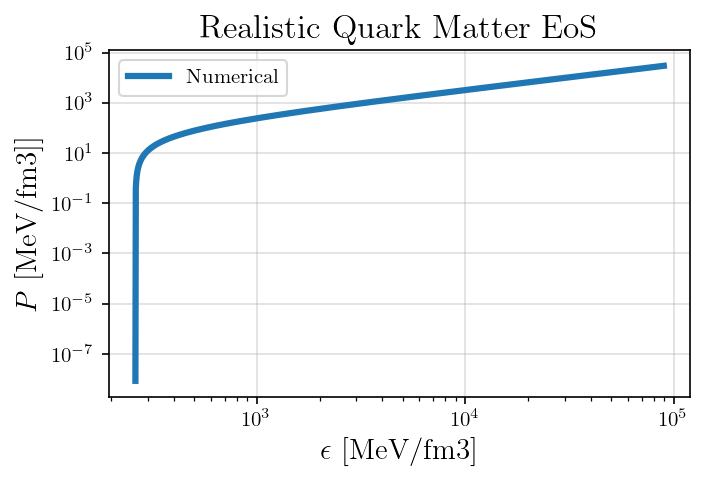

In [ ]:
# Convert to dimensionless units for plotting
units = factors_for_unit_conversion(B)
e_dim = df_real["Energy Density"] * units["factor_P_to_MeVfm3"]
p_dim = df_real["Pressure"] * units["factor_P_to_MeVfm3"]

# Check the minimum pressure point
min_pressure_index = df_real["Pressure"].idxmin()
min_pressure_value = df_real["Pressure"].iloc[min_pressure_index] * units["factor_P_to_MeVfm3"]
print(f"Minimum Pressure: {min_pressure_value:.3e} MeV/fm^3 at Energy Density: {df_real['Energy Density'].iloc[min_pressure_index]:.3e} MeV/fm^3")
plt.figure(figsize=(5,3))
plt.plot(e_dim, p_dim, label="Numerical", lw=3)
plt.xlabel(r"$\epsilon$ [MeV/fm3] ", fontsize=14)
plt.ylabel(r"$P$ [MeV/fm3]]", fontsize=14)
plt.title("Realistic Quark Matter EoS", fontsize=16)
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.grid()